<a href="https://colab.research.google.com/github/safeai-snu/finance_ai_2025/blob/main/day4/TS_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q neuralforecast
!pip show neuralforecast

from neuralforecast.models import PatchTST
from neuralforecast import NeuralForecast
from neuralforecast.models import MLP
from neuralforecast.losses.pytorch import MAE
from neuralforecast.tsdataset import TimeSeriesDataset

import pytorch_lightning as pl
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 257.7/257.7 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.8/285.8 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.1/823.1 kB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 56.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## Toy Example

In [35]:
import numpy as np
import pandas as pd
import pytorch_lightning as pl
import matplotlib.pyplot as plt

from neuralforecast import NeuralForecast
from neuralforecast.models import MLP
from neuralforecast.losses.pytorch import MQLoss, DistributionLoss
from neuralforecast.tsdataset import TimeSeriesDataset
from neuralforecast.utils import AirPassengers, AirPassengersPanel, AirPassengersStatic, augment_calendar_df

AirPassengersPanel, calendar_cols = augment_calendar_df(df=AirPassengersPanel, freq='M')

Y_train_df = AirPassengersPanel[AirPassengersPanel.ds<AirPassengersPanel['ds'].values[-12]] # 132 train
Y_test_df = AirPassengersPanel[AirPassengersPanel.ds>=AirPassengersPanel['ds'].values[-12]].reset_index(drop=True) # 12 test

In [36]:
Y_train_df

,unique_id,ds,y,trend,y_[lag12],month
0,Airline1,1949-01-31,112.0,0,112.0,-0.500000
1,Airline1,1949-02-28,118.0,1,118.0,-0.409091
2,Airline1,1949-03-31,132.0,2,132.0,-0.318182
...,...,...,...,...,...,...
273,Airline2,1959-10-31,707.0,273,659.0,0.318182
274,Airline2,1959-11-30,662.0,274,610.0,0.409091
275,Airline2,1959-12-31,705.0,275,637.0,0.500000


In [37]:
Y_test_df

,unique_id,ds,y,trend,y_[lag12],month
0,Airline1,1960-01-31,417.0,132,360.0,-0.500000
1,Airline1,1960-02-29,391.0,133,342.0,-0.409091
2,Airline1,1960-03-31,419.0,134,406.0,-0.318182
...,...,...,...,...,...,...
21,Airline2,1960-10-31,761.0,285,707.0,0.318182
22,Airline2,1960-11-30,690.0,286,662.0,0.409091
23,Airline2,1960-12-31,732.0,287,705.0,0.500000


In [38]:
model = PatchTST(h=12,
                 input_size=104,
                 patch_len=24,
                 stride=24,
                 revin=False,
                 hidden_size=16,
                 n_heads=4,
                 scaler_type='robust',
                 loss=DistributionLoss(distribution='StudentT', level=[80, 90]),
                 #loss=MAE(),
                 learning_rate=1e-3,
                 max_steps=500,
                 val_check_steps=50,
                 early_stop_patience_steps=2)

nf = NeuralForecast(
    models=[model],
    freq='M'
)
# nf.fit(df=Y_train_df, static_df=AirPassengersStatic, val_size=12)
nf.fit(df=Y_train_df, val_size=12)
forecasts = nf.predict(futr_df=Y_test_df)

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | loss         | DistributionLoss  | 5      | train
1 | padder_train | ConstantPad1d     | 0      | train
2 | scaler       | TemporalNorm      | 0      | train
3 | model        | PatchTST_backbone | 32.2 K | train
-----------------------------------------------------------
32.2 K    Trainable params
8         Non-trainable params
32.3 K    Total params
0.129     Total estimated model params size (MB)
89        Modules in train mode
0         Modules in 

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/utilsforecast/processing.py:384: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
/usr/local/lib/python3.11/dist-packages/utilsforecast/processing.py:440: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

In [39]:
Y_hat_df = forecasts.reset_index(drop=False).drop(columns=['unique_id','ds'])
Y_hat_df

,index,PatchTST,PatchTST-median,PatchTST-lo-90,PatchTST-lo-80,PatchTST-hi-80,PatchTST-hi-90
0,0,380.385651,380.843353,357.892883,363.609161,395.930817,402.230774
1,1,376.742584,376.728424,352.130005,358.850250,394.658447,401.861908
2,2,406.328583,406.552002,384.577698,389.165588,423.052521,428.409698
...,...,...,...,...,...,...,...
21,21,710.445312,710.454041,681.507874,688.162781,734.061523,740.137207
22,22,666.871643,666.300537,637.869507,643.800537,689.890686,698.334656
23,23,689.410278,689.686401,659.705750,668.084595,710.745605,717.505310


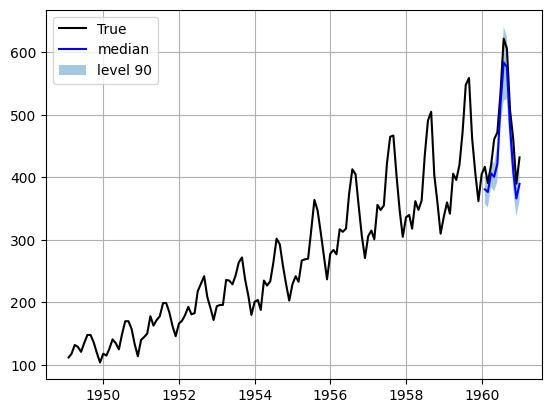

In [40]:
Y_hat_df = forecasts.reset_index(drop=False).drop(columns=['unique_id','ds'])
plot_df = pd.concat([Y_test_df, Y_hat_df], axis=1)
plot_df = pd.concat([Y_train_df, plot_df])

if model.loss.is_distribution_output:
    plot_df = plot_df[plot_df.unique_id=='Airline1'].drop('unique_id', axis=1)
    plt.plot(plot_df['ds'], plot_df['y'], c='black', label='True')
    plt.plot(plot_df['ds'], plot_df['PatchTST-median'], c='blue', label='median')
    plt.fill_between(x=plot_df['ds'][-12:],
                    y1=plot_df['PatchTST-lo-90'][-12:].values,
                    y2=plot_df['PatchTST-hi-90'][-12:].values,
                    alpha=0.4, label='level 90')
    plt.grid()
    plt.legend()
    plt.plot()
else:
    plot_df = plot_df[plot_df.unique_id=='Airline1'].drop('unique_id', axis=1)
    plt.plot(plot_df['ds'], plot_df['y'], c='black', label='True')
    plt.plot(plot_df['ds'], plot_df['PatchTST'], c='blue', label='Forecast')
    plt.legend()
    plt.grid()

In [57]:
from neuralforecast.models import NBEATS, NHITS, PatchTST, DLinear
horizon = 12

# ▒▒▒ Step 2: 모델 정의 ▒▒▒
models = [
    NBEATS(h=horizon, input_size=8*horizon, loss=MAE(), max_steps=300),
    NHITS(h=horizon, input_size=8*horizon, loss=MAE(), max_steps=300),
    DLinear(h=horizon, input_size=8*horizon, loss=MAE(), max_steps=300),
    #PatchTST(h=horizon, input_size=8*horizon, loss=MAE(), max_steps=300),
    PatchTST(h=horizon,
            input_size=8*horizon,
            patch_len=24,
            stride=24,
            revin=False,
            hidden_size=16,
            n_heads=4,
            scaler_type='robust',
            loss=MAE(),
            learning_rate=1e-3,
            max_steps=300,
            val_check_steps=50,
            early_stop_patience_steps=2)
]

# ▒▒▒ Step 3: 학습 ▒▒▒
nf = NeuralForecast(models=models, freq='M')
nf.fit(df=Y_train_df, val_size=horizon)

# ▒▒▒ Step 4: 예측 ▒▒▒
#forecasts = nf.predict()
forecasts = nf.predict(futr_df=Y_test_df)

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 2.6 M  | train
-------------------------------------------------------
2.6 M     Trainable params
2.7 K     Non-trainable params


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Predicting: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

In [58]:
from sklearn.metrics import mean_absolute_error

mae_scores = {}
for col in forecasts.columns:
    if col.startswith('ds') or col.startswith('unique_id'):
        continue
    y_true = Y_test_df[Y_test_df['unique_id']=='Airline1']['y'].values
    y_pred = forecasts[forecasts['unique_id'] == 'Airline1'][col].values
    y_pred = y_pred[:len(y_true)]
    mae_scores[col] = mean_absolute_error(y_true, y_pred)

print("🔎 MAE Scores:")
for model, score in mae_scores.items():
    print(f"{model}: {score:.3f}")

🔎 MAE Scores:
NBEATS: 14.666
NHITS: 17.710
DLinear: 78.726
PatchTST: 16.212


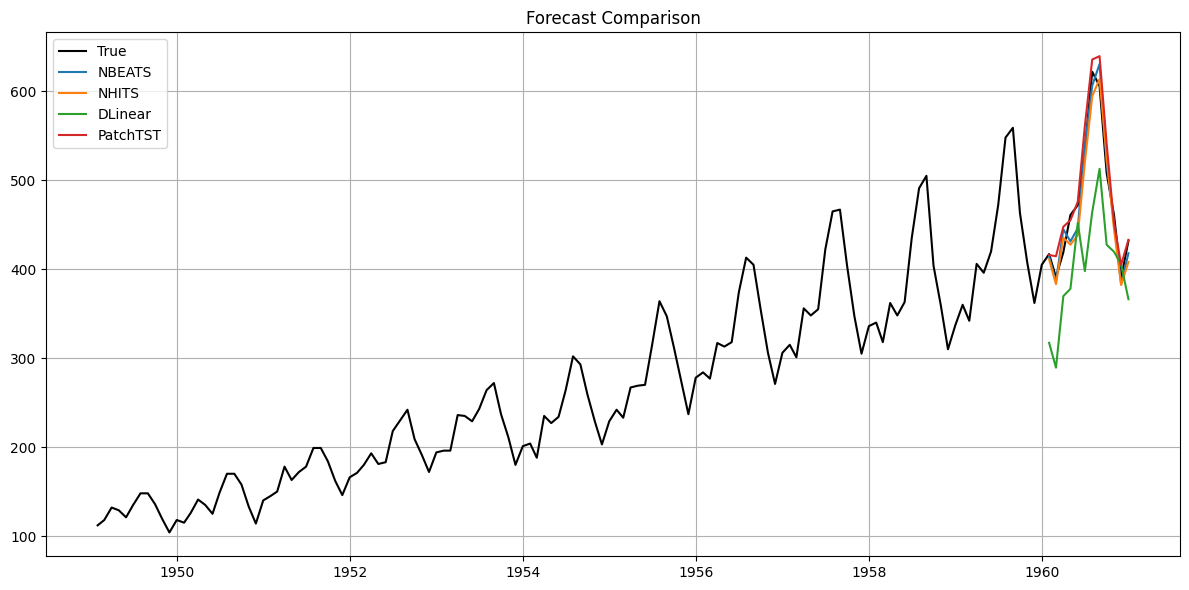

In [59]:
# ▒▒▒ Step 6: 시각화 ▒▒▒
import matplotlib.pyplot as plt

Y_hat_df = forecasts.reset_index(drop=False).drop(columns=['unique_id','ds'])
plot_df = pd.concat([Y_test_df, Y_hat_df], axis=1)
plot_df = pd.concat([Y_train_df, plot_df])

plot_df = plot_df[plot_df['unique_id'] == 'Airline1']

plt.figure(figsize=(12, 6))
plt.plot(plot_df['ds'], plot_df['y'], label='True', c='black')

for col in forecasts.columns:
    if 'median' in col or col.startswith('ds') or col.startswith('unique_id'):
        continue
    if 'PatchTST' in col and '-lo-' in col:
        continue  # Skip low/high intervals for now
    plt.plot(plot_df['ds'], plot_df[col], label=col)

# 예: PatchTST의 신뢰구간 시각화
if 'PatchTST-median' in plot_df.columns:
    plt.plot(plot_df['ds'], plot_df['PatchTST-median'], label='PatchTST-median', c='blue')
    plt.fill_between(
        x=plot_df['ds'][-horizon:],
        y1=plot_df['PatchTST-lo-90'][-horizon:].values,
        y2=plot_df['PatchTST-hi-90'][-horizon:].values,
        alpha=0.3,
        label='PatchTST 90% CI'
    )

plt.legend()
plt.title("Forecast Comparison")
plt.grid()
plt.tight_layout()
plt.show()

## StatsForecast

In [61]:
!pip install statsforecast

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.4/354.4 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.3/135.3 kB 13.0 MB/s eta 0:00:00


In [184]:
# import matplotlib.pyplot as plt

# plt.style.use('fivethirtyeight')
# plt.rcParams['lines.linewidth'] = 1.5
# dark_style = {
#     'figure.facecolor': '#212946',
#     'axes.facecolor': '#212946',
#     'savefig.facecolor':'#212946',
#     'axes.grid': True,
#     'axes.grid.which': 'both',
#     'axes.spines.left': False,
#     'axes.spines.right': False,
#     'axes.spines.top': False,
#     'axes.spines.bottom': False,
#     'grid.color': '#2A3459',
#     'grid.linewidth': '1',
#     'text.color': '0.9',
#     'axes.labelcolor': '0.9',
#     'xtick.color': '0.9',
#     'ytick.color': '0.9',
#     'font.size': 12 }
# plt.rcParams.update(dark_style)

# from pylab import rcParams
# rcParams['figure.figsize'] = (18,7)

import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
plt.style.use('fivethirtyeight')
plt.rcParams['lines.linewidth'] = 1.5
dark_style = {
    'figure.facecolor': '#212946',
    'axes.facecolor': '#212946',
    'savefig.facecolor':'#212946',
    'axes.grid': True,
    'axes.grid.which': 'both',
    'axes.spines.left': False,
    'axes.spines.right': False,
    'axes.spines.top': False,
    'axes.spines.bottom': False,
    'grid.color': '#2A3459',
    'grid.linewidth': '1',
    'text.color': '0.9',
    'axes.labelcolor': '0.9',
    'xtick.color': '0.9',
    'ytick.color': '0.9',
    'font.size': 12 }
plt.rcParams.update(dark_style)

from pylab import rcParams
rcParams['figure.figsize'] = (18,7)

In [186]:
df = pd.read_csv("https://raw.githubusercontent.com/Naren8520/Serie-de-tiempo-con-Machine-Learning/main/Data/candy_production.csv")
df.head()

,observation_date,IPG3113N
0,1972-01-01,85.6945
1,1972-02-01,71.8200
2,1972-03-01,66.0229
3,1972-04-01,64.5645
4,1972-05-01,65.0100


In [187]:
df["unique_id"]="1"
df.columns=["ds", "y", "unique_id"]
df.head()

,ds,y,unique_id
0,1972-01-01,85.6945,1
1,1972-02-01,71.8200,1
2,1972-03-01,66.0229,1
3,1972-04-01,64.5645,1
4,1972-05-01,65.0100,1


In [188]:
# df_p = AirPassengersPanel[['ds', 'y', 'unique_id']]
# df_p

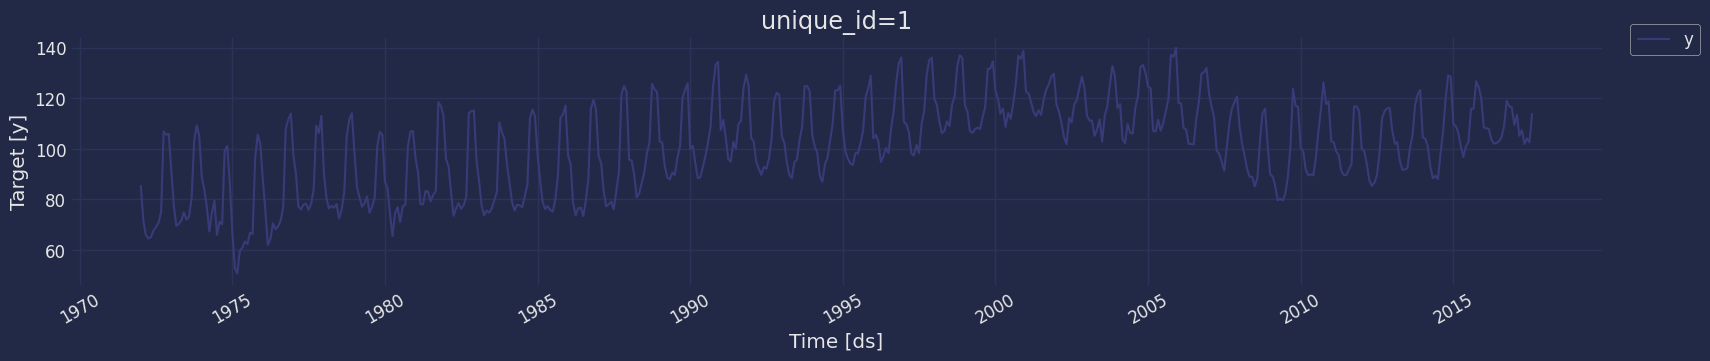

In [189]:
StatsForecast.plot(df)

,y
count,548.000000
mean,100.662524
std,18.052931
...,...
50%,102.278550
75%,114.691900
max,139.915300


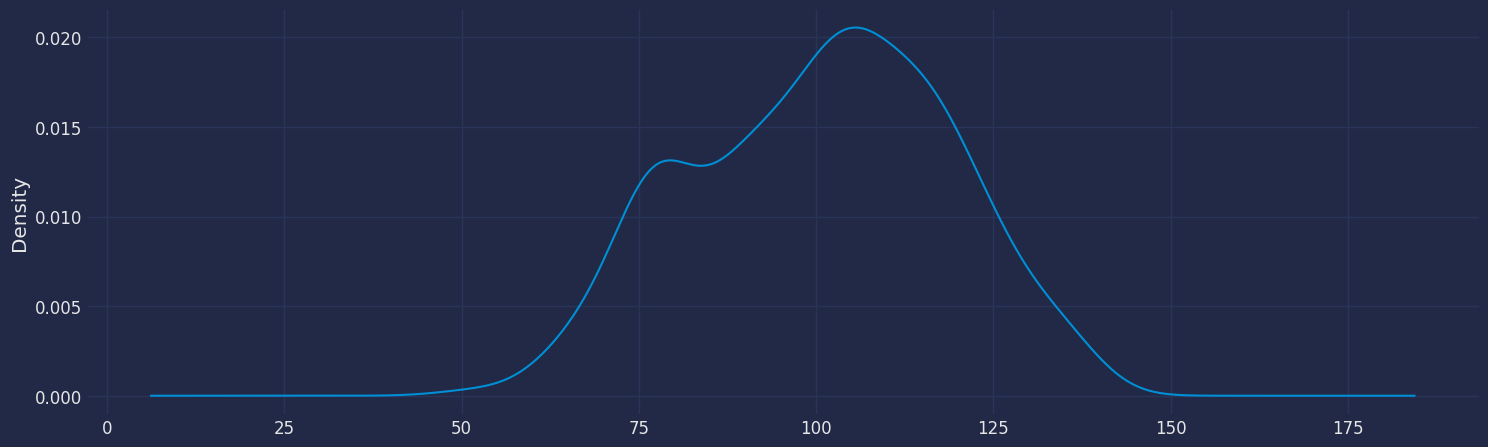

In [190]:
#df = df_p[df_p['unique_id']=='Airline1']
df["y"].plot(kind='kde',figsize = (16,5))
df["y"].describe()

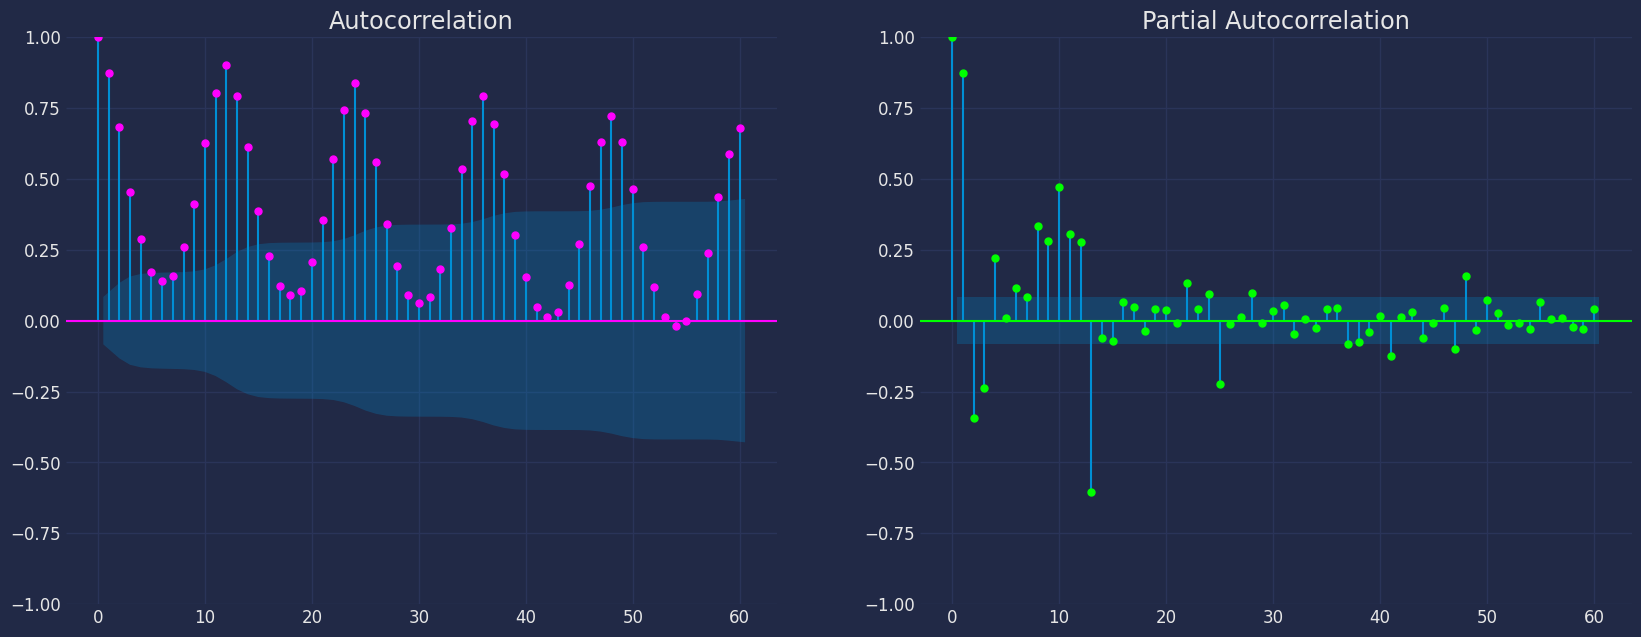

In [191]:
# Autocorrelation plot
fig, axs = plt.subplots(nrows=1, ncols=2)

plot_acf(df["y"],  lags=60, ax=axs[0],color="fuchsia")
axs[0].set_title("Autocorrelation");

plot_pacf(df["y"],  lags=60, ax=axs[1],color="lime")
axs[1].set_title('Partial Autocorrelation')

plt.show();

In [166]:
from statsmodels.tsa.seasonal import seasonal_decompose

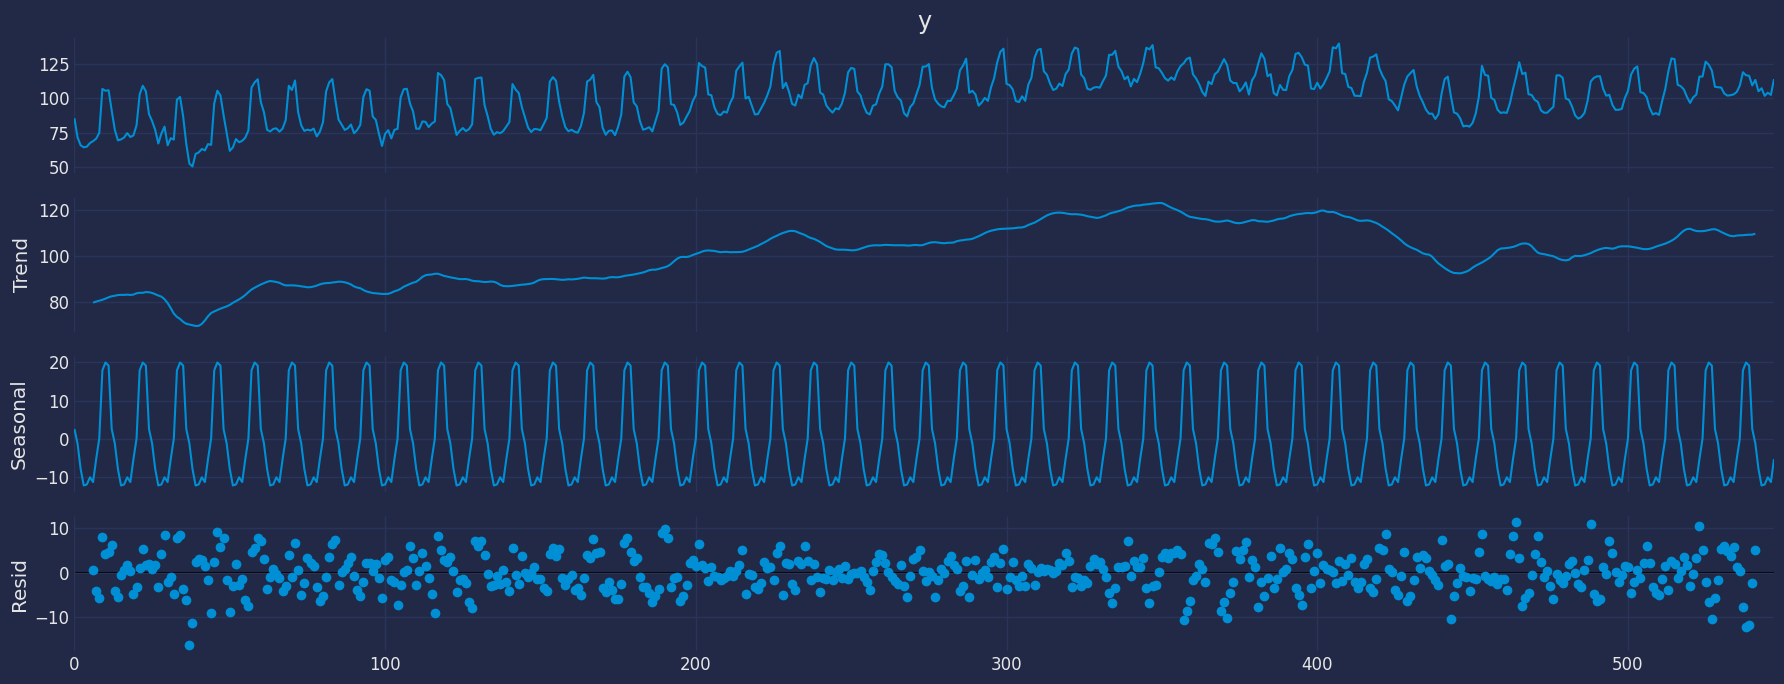

In [193]:
decomposed=seasonal_decompose(df["y"], model = "add", period=12)
decomposed.plot()
plt.show()

In [194]:
from statsmodels.tsa.stattools import adfuller

In [195]:
def Augmented_Dickey_Fuller_Test_func(series , column_name):
    print (f'Dickey-Fuller test results for columns: {column_name}')
    dftest = adfuller(series, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','No Lags Used','Number of observations used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print (dfoutput)
    if dftest[1] <= 0.05:
        print("Conclusion:====>")
        print("Reject the null hypothesis")
        print("The data is stationary")
    else:
        print("Conclusion:====>")
        print("The null hypothesis cannot be rejected")
        print("The data is not stationary")

In [196]:
Augmented_Dickey_Fuller_Test_func(df["y"],"Passengers")

Dickey-Fuller test results for columns: Passengers
Test Statistic          -1.887050
p-value                  0.338178
No Lags Used            14.000000
                          ...    
Critical Value (1%)     -3.442678
Critical Value (5%)     -2.866978
Critical Value (10%)    -2.569666
Length: 7, dtype: float64
Conclusion:====>
The null hypothesis cannot be rejected
The data is not stationary


In [197]:
df1=df.copy()
df1['y_diff'] = df['y'].diff()
df1.dropna(inplace=True)
df1.head()

,ds,y,unique_id,y_diff
1,1972-02-01,71.8200,1,-13.8745
2,1972-03-01,66.0229,1,-5.7971
3,1972-04-01,64.5645,1,-1.4584
4,1972-05-01,65.0100,1,0.4455
5,1972-06-01,67.6467,1,2.6367


In [198]:
Augmented_Dickey_Fuller_Test_func(df1["y_diff"],"Passengers_diff")

Dickey-Fuller test results for columns: Passengers_diff
Test Statistic         -6.119512e+00
p-value                 8.925584e-08
No Lags Used            1.300000e+01
                            ...     
Critical Value (1%)    -3.442678e+00
Critical Value (5%)    -2.866978e+00
Critical Value (10%)   -2.569666e+00
Length: 7, dtype: float64
Conclusion:====>
Reject the null hypothesis
The data is stationary


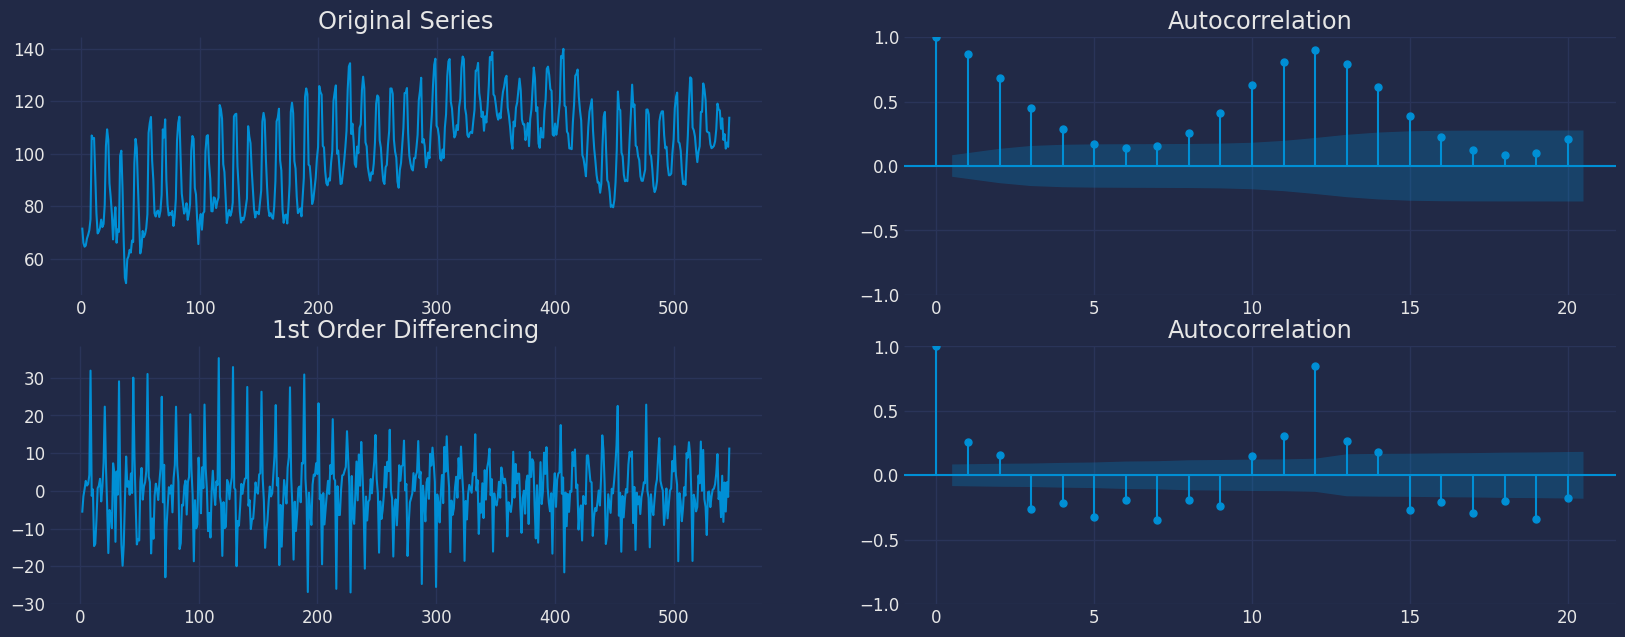

In [199]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt


fig, axes = plt.subplots(2, 2, )
axes[0, 0].plot(df1["y"]); axes[0, 0].set_title('Original Series')
plot_acf(df1["y"], ax=axes[0, 1],lags=20)

axes[1, 0].plot(df1["y"].diff()); axes[1, 0].set_title('1st Order Differencing')
plot_acf(df1["y"].diff().dropna(), ax=axes[1, 1],lags=20)


plt.show()

In [128]:
## Model Evaluation

In [204]:
df["ds"] = pd.to_datetime(df["ds"])

Y_train_df = df[df.ds<='2016-08-01']
Y_test_df = df[df.ds>'2016-08-01']
Y_train_df.shape, Y_test_df.shape

((536, 3), (12, 3))

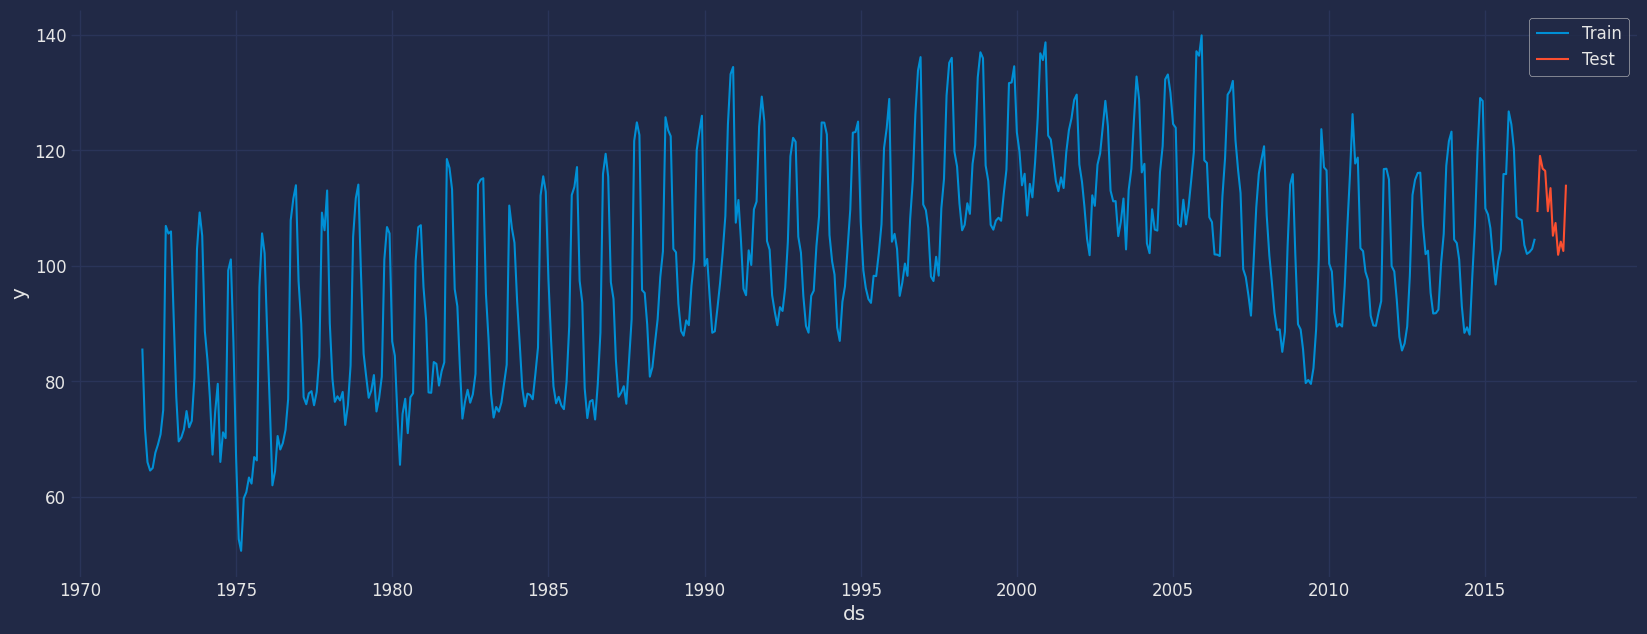

In [205]:
sns.lineplot(Y_train_df,x="ds", y="y", label="Train")
sns.lineplot(Y_test_df, x="ds", y="y", label="Test")
plt.show()

In [206]:
## AutoArima with StatsForecast

In [207]:
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA
from statsforecast.arima import arima_string

In [208]:
season_length = 12 # Monthly data
horizon = len(Y_test_df) # number of predictions

models = [AutoARIMA(season_length=season_length)]

In [209]:
sf = StatsForecast(models=models, freq='MS')
sf.fit(df=Y_train_df)

StatsForecast(models=[AutoARIMA])

In [210]:
arima_string(sf.fitted_[0,0].model_)

'ARIMA(4,0,3)(0,1,1)[12]                   '

In [211]:
result=sf.fitted_[0,0].model_
print(result.keys())
print(result['arma'])

dict_keys(['coef', 'sigma2', 'var_coef', 'mask', 'loglik', 'aic', 'arma', 'residuals', 'code', 'n_cond', 'nobs', 'model', 'bic', 'aicc', 'ic', 'xreg', 'x', 'lambda'])
(4, 3, 0, 1, 12, 0, 1)


In [212]:
residual=pd.DataFrame(result.get("residuals"), columns=["residual Model"])
residual

,residual Model
0,0.085694
1,0.071820
2,0.066022
...,...
533,1.615486
534,-0.394285
535,-6.733548


<ipython-input-215-5137de7113d4>:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residual, ax=axs[0,1]);


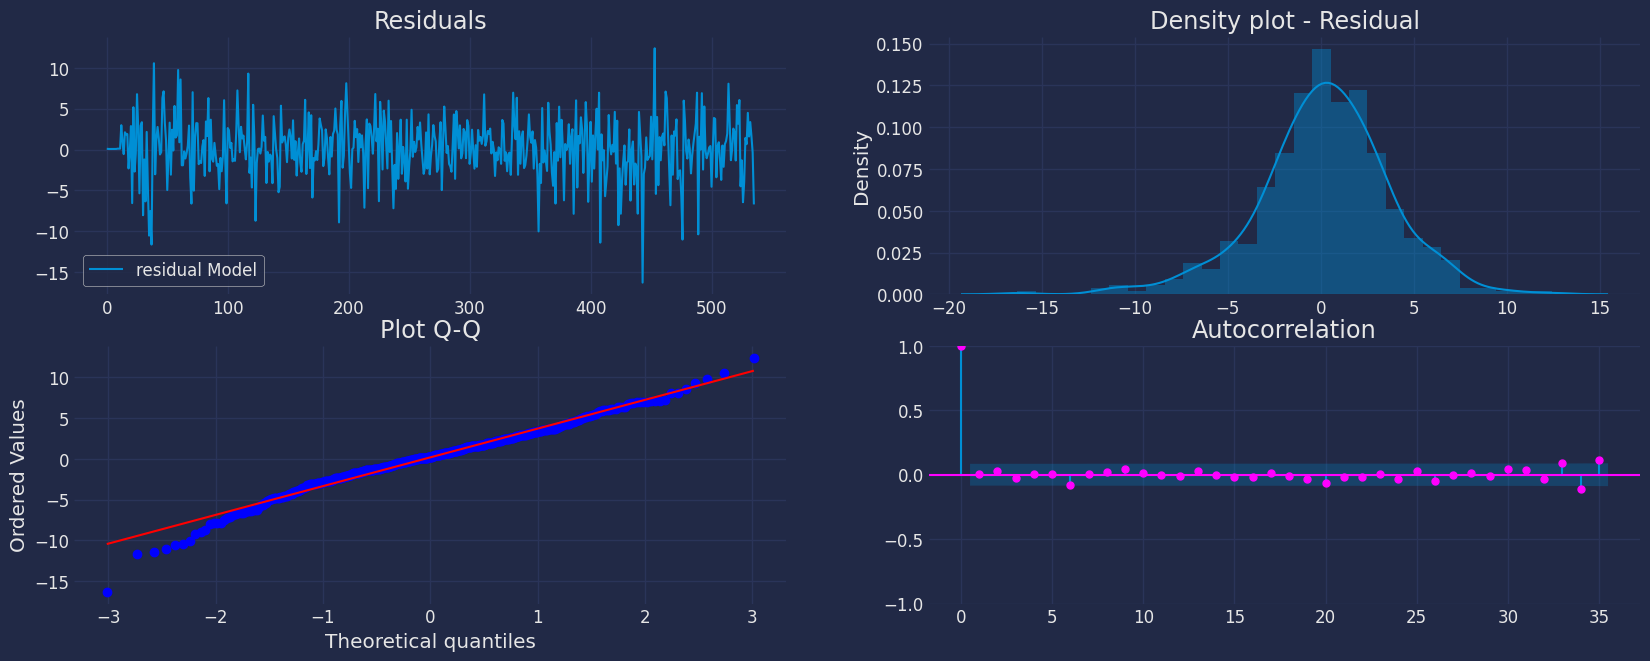

In [215]:
from scipy import stats


fig, axs = plt.subplots(nrows=2, ncols=2)

# plot[1,1]
residual.plot(ax=axs[0,0])
axs[0,0].set_title("Residuals");

# plot
sns.distplot(residual, ax=axs[0,1]);
axs[0,1].set_title("Density plot - Residual");

# plot
stats.probplot(residual["residual Model"], dist="norm", plot=axs[1,0])
axs[1,0].set_title('Plot Q-Q')

# plot
plot_acf(residual,  lags=35, ax=axs[1,1],color="fuchsia")
axs[1,1].set_title("Autocorrelation");

plt.show();

In [214]:
Y_hat_df = sf.forecast(df=Y_train_df, h=horizon, fitted=True)
Y_hat_df.head()

,unique_id,ds,AutoARIMA
0,1,2016-09-01,111.235874
1,1,2016-10-01,124.948376
2,1,2016-11-01,125.401640
3,1,2016-12-01,123.854827
4,1,2017-01-01,110.439452


In [216]:
values=sf.forecast_fitted_values()
values

,unique_id,ds,y,AutoARIMA
0,1,1972-01-01,85.6945,85.608806
1,1,1972-02-01,71.8200,71.748180
2,1,1972-03-01,66.0229,65.956878
...,...,...,...,...
533,1,2016-06-01,102.4044,100.788914
534,1,2016-07-01,102.9512,103.345485
535,1,2016-08-01,104.6977,111.431248


In [217]:
sf.forecast(df=Y_train_df, h=12, level=[95])

,unique_id,ds,AutoARIMA,AutoARIMA-lo-95,AutoARIMA-hi-95
0,1,2016-09-01,111.235874,104.140621,118.331128
1,1,2016-10-01,124.948376,116.244661,133.652090
2,1,2016-11-01,125.401640,115.882093,134.921186
...,...,...,...,...,...
9,1,2017-06-01,98.304448,85.884576,110.724320
10,1,2017-07-01,99.630308,87.032359,112.228256
11,1,2017-08-01,105.426710,92.639162,118.214258


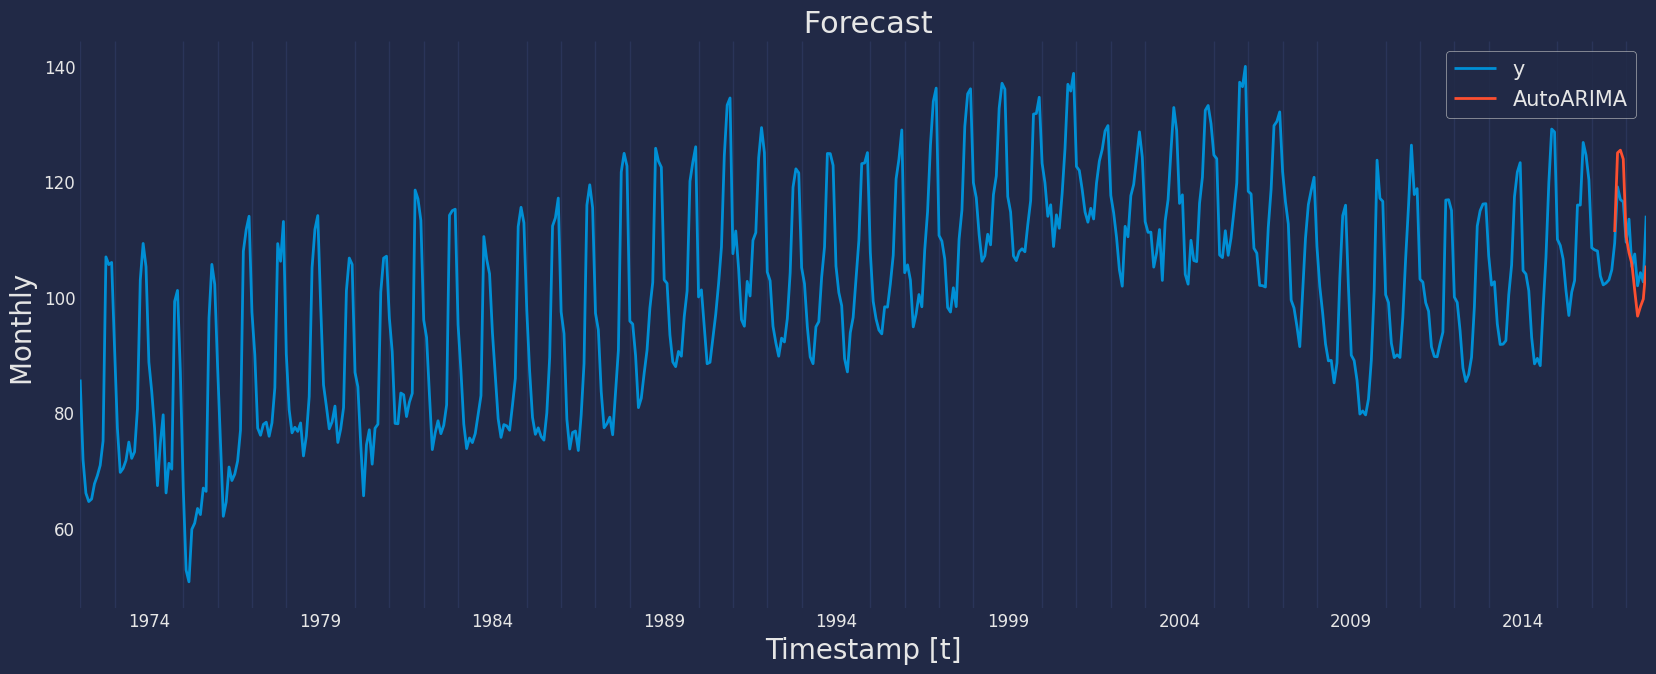

In [218]:
Y_hat_df = Y_test_df.merge(Y_hat_df, how='left', on=['unique_id', 'ds'])

fig, ax = plt.subplots(1, 1, figsize = (18, 7))
plot_df = pd.concat([Y_train_df, Y_hat_df]).set_index('ds')
plot_df[['y', 'AutoARIMA']].plot(ax=ax, linewidth=2)
ax.set_title(' Forecast', fontsize=22)
ax.set_ylabel('Monthly ', fontsize=20)
ax.set_xlabel('Timestamp [t]', fontsize=20)
ax.legend(prop={'size': 15})
ax.grid()

In [219]:
Y_hat_df

,ds,y,unique_id,AutoARIMA
0,2016-09-01,109.3191,1,111.235874
1,2016-10-01,119.0502,1,124.948376
2,2016-11-01,116.8431,1,125.401640
...,...,...,...,...
9,2017-06-01,104.2022,1,98.304448
10,2017-07-01,102.5861,1,99.630308
11,2017-08-01,114.0613,1,105.426710


In [223]:
from functools import partial

import utilsforecast.losses as ufl
from utilsforecast.evaluation import evaluate

In [224]:
evaluate(
    Y_test_df.merge(Y_hat_df),
    metrics=[ufl.mae, ufl.mape, partial(ufl.mase, seasonality=season_length), ufl.rmse, ufl.smape],
    train_df=Y_train_df,
)

,unique_id,metric,AutoARIMA
0,1,mae,5.012894
1,1,mape,0.045046
2,1,mase,0.967601
3,1,rmse,5.680362
4,1,smape,0.022673
